1. Environment & Reproducibility
This experiment is executed locally on an Apple Silicon M4 Pro machine using PyTorch with the Metal Performance Shaders (MPS) backend for hardware acceleration.
A project-specific Python virtual environment is used to isolate dependencies from the global Python installation and improve reproducibility.
To reduce variability between experiment runs, random seeds are fixed across Python, NumPy, and PyTorch.
The primary model selected for this case study is:
google/flan-t5-small
The model was selected because it is lightweight enough for laptop-scale experimentation while still supporting sequence-to-sequence generation tasks such as dialogue summarization.
The experiment will use the same fixed seed and evaluation protocol when comparing the baseline and fine-tuned models.

In [8]:
# ============================================================
# Environment and reproducibility configuration
# ============================================================

import os
import sys
import random
import platform
from pathlib import Path

import numpy as np
import torch
import transformers


# ------------------------------------------------------------
# 1. Set a fixed random seed
# ------------------------------------------------------------
#
# A fixed seed improves reproducibility by reducing variation
# caused by random initialization, data shuffling, and other
# stochastic operations.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# 2. Select the best available compute device
# ------------------------------------------------------------
#
# On this machine, PyTorch MPS provides GPU acceleration through
# Apple's Metal framework.
#
# Fallback order:
#   1. MPS
#   2. CUDA
#   3. CPU

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")

elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")

else:
    DEVICE = torch.device("cpu")


# ------------------------------------------------------------
# 3. Define experiment constants
# ------------------------------------------------------------

MODEL_NAME = "google/flan-t5-small"

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DATA_DIR = DATA_DIR / "processed"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"


# ------------------------------------------------------------
# 4. Create directories if they do not already exist
# ------------------------------------------------------------

for directory in [
    PROCESSED_DATA_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 5. Display environment details
# ------------------------------------------------------------

print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)

print(f"Python executable    : {sys.executable}")
print(f"Python version       : {sys.version.split()[0]}")
print(f"Operating system     : {platform.platform()}")
print(f"PyTorch version      : {torch.__version__}")
print(f"Transformers version : {transformers.__version__}")
print(f"MPS available        : {torch.backends.mps.is_available()}")
print(f"Selected device      : {DEVICE}")
print(f"Random seed          : {SEED}")
print(f"Selected model       : {MODEL_NAME}")

print("=" * 70)

ENVIRONMENT INFORMATION
Python executable    : /Users/shashankkowtharapu/Desktop/KPMG/.venv/bin/python
Python version       : 3.14.6
Operating system     : macOS-26.6.1-arm64-arm-64bit-Mach-O
PyTorch version      : 2.13.0
Transformers version : 5.15.0
MPS available        : True
Selected device      : mps
Random seed          : 42
Selected model       : google/flan-t5-small


In [9]:
from pathlib import Path

# Get the notebook's current working directory.
CURRENT_DIR = Path.cwd()

# If Jupyter is running from the "notebooks" directory,
# move one level up to find the actual KPMG project root.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Define all project directories relative to the project root.
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("Data directory    :", DATA_DIR)
print("Output directory  :", OUTPUT_DIR)

Current directory : /Users/shashankkowtharapu/Desktop/KPMG/notebooks
Project root      : /Users/shashankkowtharapu/Desktop/KPMG
Data directory    : /Users/shashankkowtharapu/Desktop/KPMG/data
Output directory  : /Users/shashankkowtharapu/Desktop/KPMG/outputs


Dataset validation of slits, and column names

In [5]:
from datasets import load_dataset

# Load the DialogSum dataset from Hugging Face
dataset = load_dataset("knkarthick/dialogsum")

# Display available dataset splits
print(dataset)
print("dataset print complete")

# Inspect the column names for each split
for split_name in dataset.keys():
    print(f"{split_name}: {dataset[split_name].column_names}")

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})
dataset print complete
train: ['id', 'dialogue', 'summary', 'topic']
validation: ['id', 'dialogue', 'summary', 'topic']
test: ['id', 'dialogue', 'summary', 'topic']


EDA block focused on data quality first: missing values and duplicates.

In [11]:
# Basic data quality checks

for split_name in ["train", "validation", "test"]:
    split = dataset[split_name]

    print(f"\n--- {split_name.upper()} ---")

    # Missing values
    missing_dialogue = sum(x is None or str(x).strip() == "" for x in split["dialogue"])
    missing_summary = sum(x is None or str(x).strip() == "" for x in split["summary"])

    print("Missing dialogues:", missing_dialogue)
    print("Missing summaries:", missing_summary)

    # Duplicate checks
    duplicate_dialogues = len(split["dialogue"]) - len(set(split["dialogue"]))
    duplicate_summaries = len(split["summary"]) - len(set(split["summary"]))

    print("Duplicate dialogues:", duplicate_dialogues)
    print("Duplicate summaries:", duplicate_summaries)


--- TRAIN ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 2
Duplicate summaries: 24

--- VALIDATION ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 0
Duplicate summaries: 0

--- TEST ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 1000
Duplicate summaries: 13


In [12]:
from collections import Counter

# Find repeated dialogues in the test set
test_dialogues = dataset["test"]["dialogue"]
dialogue_counts = Counter(test_dialogues)

repeated_dialogues = {
    dialogue: count
    for dialogue, count in dialogue_counts.items()
    if count > 1
}

print("Unique repeated dialogues:", len(repeated_dialogues))

# Inspect one repeated dialogue and its associated summaries
sample_dialogue = next(iter(repeated_dialogues))

print("\nDialogue:")
print(sample_dialogue)

print("\nReference summaries:")

for row in dataset["test"]:
    if row["dialogue"] == sample_dialogue:
        print("-", row["summary"])

Unique repeated dialogues: 500

Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much ti

In [13]:
from transformers import AutoTokenizer
import numpy as np

model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def get_token_lengths(texts):
    return [
        len(tokenizer(text, truncation=False)["input_ids"])
        for text in texts
    ]

train_dialogue_lengths = get_token_lengths(dataset["train"]["dialogue"])
train_summary_lengths = get_token_lengths(dataset["train"]["summary"])

print("Dialogue token lengths")
print("Mean:", round(np.mean(train_dialogue_lengths), 2))
print("Median:", np.median(train_dialogue_lengths))
print("95th percentile:", np.percentile(train_dialogue_lengths, 95))
print("99th percentile:", np.percentile(train_dialogue_lengths, 99))
print("Max:", max(train_dialogue_lengths))

print("\nSummary token lengths")
print("Mean:", round(np.mean(train_summary_lengths), 2))
print("Median:", np.median(train_summary_lengths))
print("95th percentile:", np.percentile(train_summary_lengths, 95))
print("99th percentile:", np.percentile(train_summary_lengths, 99))
print("Max:", max(train_summary_lengths))

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (517 > 512). Running this sequence through the model will result in indexing errors


Dialogue token lengths
Mean: 224.4
Median: 202.0
95th percentile: 416.0
99th percentile: 614.4099999999999
Max: 1569

Summary token lengths
Mean: 41.27
Median: 38.0
95th percentile: 73.0
99th percentile: 96.0
Max: 277


In [14]:
max_input_length = 512
max_target_length = 128

def preprocess_function(examples):
    # Add an instruction prefix for FLAN-T5
    inputs = [
        "Summarize the following dialogue: " + dialogue
        for dialogue in examples["dialogue"]
    ]

    # Tokenize input dialogues
    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True
    )

    # Tokenize reference summaries as target labels
    labels = tokenizer(
        text_target=examples["summary"],
        max_length=max_target_length,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [15]:
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print(tokenized_dataset)

Map:   0%|          | 0/12460 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1500
    })
})


In [16]:
import torch

from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)

model_name = "google/flan-t5-small"

# Select Apple Silicon GPU if available
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Using device:", device)

# Load the pretrained FLAN-T5-Small model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Move model to the selected device
model = model.to(device)

# Dynamically pad inputs and labels within each batch
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

print("Model loaded successfully.")

Using device: mps


model.safetensors: reconstructing file:   0%|          |  0.00B /  308MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully.


In [17]:
def generate_summary(dialogue):
    prompt = "Summarize the following dialogue: " + dialogue

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4
        )

    return tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )


# Inspect a few baseline predictions
for i in range(3):
    example = dataset["test"][i]

    prediction = generate_summary(example["dialogue"])

    print(f"\n--- Sample {i + 1} ---")
    print("\nDialogue:")
    print(example["dialogue"])

    print("\nReference Summary:")
    print(example["summary"])

    print("\nBaseline FLAN-T5 Summary:")
    print(prediction)


--- Sample 1 ---

Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much time! Now, plea

In [18]:
seen_dialogues = set()
sample_count = 0

for example in dataset["test"]:
    dialogue = example["dialogue"]

    if dialogue in seen_dialogues:
        continue

    seen_dialogues.add(dialogue)

    prediction = generate_summary(dialogue)

    print(f"\n--- Unique Sample {sample_count + 1} ---")

    print("\nReference Summary:")
    print(example["summary"])

    print("\nBaseline FLAN-T5 Summary:")
    print(prediction)

    sample_count += 1

    if sample_count == 3:
        break


--- Unique Sample 1 ---

Reference Summary:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

Baseline FLAN-T5 Summary:
#Person2#: Thank you, sir.

--- Unique Sample 2 ---

Reference Summary:
#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.

Baseline FLAN-T5 Summary:
Taking the subway would be a lot less stressful than driving.

--- Unique Sample 3 ---

Reference Summary:
#Person1# tells Kate that Masha and Hero get divorced. Kate is surprised because she thought they are perfect couple.

Baseline FLAN-T5 Summary:
Masha and Hero are getting divorced.


In [19]:
import evaluate

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")

In [20]:
from collections import defaultdict
from tqdm.auto import tqdm

# Group multiple reference summaries by unique dialogue
test_references = defaultdict(list)

for row in dataset["test"]:
    test_references[row["dialogue"]].append(row["summary"])

unique_dialogues = list(test_references.keys())

print("Unique test dialogues:", len(unique_dialogues))

Unique test dialogues: 500


In [22]:
baseline_predictions = []
baseline_references = []

model.eval()

for dialogue in tqdm(unique_dialogues):
    prediction = generate_summary(dialogue)

    baseline_predictions.append(prediction)

    # Keep all human-written references for this dialogue
    baseline_references.append(test_references[dialogue])

  0%|          | 0/500 [00:00<?, ?it/s]

In [23]:
# ROUGE can evaluate each generated summary
# against its corresponding references
rouge_results = rouge_metric.compute(
    predictions=baseline_predictions,
    references=baseline_references,
    use_stemmer=True
)

print("Baseline ROUGE Scores")

for metric_name, score in rouge_results.items():
    print(f"{metric_name}: {score:.4f}")

Baseline ROUGE Scores
rouge1: 0.2193
rouge2: 0.0811
rougeL: 0.1932
rougeLsum: 0.1934


In [24]:
bleu_results = bleu_metric.compute(
    predictions=baseline_predictions,
    references=baseline_references
)

print("\nBaseline BLEU Score:")
print(f"BLEU: {bleu_results['score']:.2f}")


Baseline BLEU Score:
BLEU: 6.96


In [25]:
training_config = {
    "learning_rate": 5e-5,
    "train_batch_size": 4,
    "eval_batch_size": 4,
    "num_train_epochs": 3,
    "weight_decay": 0.01,
    "gradient_accumulation_steps": 2
}

In [26]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-dialogsum",

    learning_rate=5e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=100,

    save_total_limit=2,

    report_to="none"
)

In [29]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator
)

print("Trainer configured successfully.")

Trainer configured successfully.


In [30]:
batch = data_collator([
    tokenized_dataset["train"][0],
    tokenized_dataset["train"][1]
])

print(batch.keys())
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

KeysView({'input_ids': tensor([[12198,  1635,  1737,     8,   826,  7478,    10,  1713,   345, 13515,
           536,  4663,    10,  2018,     6,  1363,     5,  3931,     5,    27,
            31,    51,  7582, 12833,    77,     7,     5,  1615,    33,    25,
           270,   469,    58,  1713,   345, 13515,   357,  4663,    10,    27,
           435,    34,   133,    36,     3,     9,   207,   800,    12,   129,
             3,     9,   691,    18,   413,     5,  1713,   345, 13515,   536,
          4663,    10,  2163,     6,   168,     6,    25,    43,    29,    31,
            17,   141,    80,    21,   305,   203,     5,   148,   225,    43,
            80,   334,   215,     5,  1713,   345, 13515,   357,  4663,    10,
            27,   214,     5,    27,  2320,    38,   307,    38,   132,    19,
          1327,  1786,     6,   572,   281,   217,     8,  2472,    58,  1713,
           345, 13515,   536,  4663,    10,  1548,     6,     8,   200,   194,
            12,  1792,  2261,

In [31]:
train_result = trainer.train()

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,2.777563,1.229860
2,2.667671,1.190752
3,2.580455,1.185758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [32]:
# Save the fine-tuned model and tokenizer
trainer.save_model("./flan-t5-dialogsum-final")
tokenizer.save_pretrained("./flan-t5-dialogsum-final")

print("Fine-tuned model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved successfully.


In [33]:
print("Training metrics:")
print(train_result.metrics)

Training metrics:
{'train_runtime': 1969.434, 'train_samples_per_second': 18.98, 'train_steps_per_second': 2.373, 'total_flos': 4549797902352384.0, 'train_loss': 2.7052403924604946, 'epoch': 3.0}


In [34]:
for log in trainer.state.log_history:
    if "loss" in log or "eval_loss" in log:
        print(log)

{'loss': 3.3159124755859377, 'grad_norm': 4.340989112854004, 'learning_rate': 4.894094993581515e-05, 'epoch': 0.06420545746388442, 'step': 100}
{'loss': 3.068994140625, 'grad_norm': 5.497532844543457, 'learning_rate': 4.787120239623449e-05, 'epoch': 0.12841091492776885, 'step': 200}
{'loss': 3.053851318359375, 'grad_norm': 6.194333076477051, 'learning_rate': 4.680145485665383e-05, 'epoch': 0.1926163723916533, 'step': 300}
{'loss': 2.9444091796875, 'grad_norm': 3.974874258041382, 'learning_rate': 4.573170731707318e-05, 'epoch': 0.2568218298555377, 'step': 400}
{'loss': 2.884541015625, 'grad_norm': 4.937041282653809, 'learning_rate': 4.466195977749251e-05, 'epoch': 0.32102728731942215, 'step': 500}
{'loss': 2.8703741455078124, 'grad_norm': 4.656736850738525, 'learning_rate': 4.3592212237911855e-05, 'epoch': 0.3852327447833066, 'step': 600}
{'loss': 2.8294512939453127, 'grad_norm': 4.338695526123047, 'learning_rate': 4.252246469833119e-05, 'epoch': 0.449438202247191, 'step': 700}
{'loss':

In [35]:
fine_tuned_predictions = []
fine_tuned_references = []

model.eval()

for dialogue in tqdm(unique_dialogues):
    prediction = generate_summary(dialogue)

    fine_tuned_predictions.append(prediction)
    fine_tuned_references.append(test_references[dialogue])

  0%|          | 0/500 [00:00<?, ?it/s]

In [36]:
fine_tuned_rouge = rouge_metric.compute(
    predictions=fine_tuned_predictions,
    references=fine_tuned_references,
    use_stemmer=True
)

print("Fine-Tuned ROUGE Scores")

for metric_name, score in fine_tuned_rouge.items():
    print(f"{metric_name}: {score:.4f}")

Fine-Tuned ROUGE Scores
rouge1: 0.4789
rouge2: 0.2288
rougeL: 0.3971
rougeLsum: 0.3968


In [37]:
fine_tuned_bleu = bleu_metric.compute(
    predictions=fine_tuned_predictions,
    references=fine_tuned_references
)

print("\nFine-Tuned BLEU Score:")
print(f"BLEU: {fine_tuned_bleu['score']:.2f}")


Fine-Tuned BLEU Score:
BLEU: 25.57


In [38]:
seen_dialogues = set()
sample_count = 0

for example in dataset["test"]:
    dialogue = example["dialogue"]

    if dialogue in seen_dialogues:
        continue

    seen_dialogues.add(dialogue)

    fine_tuned_prediction = generate_summary(dialogue)

    print(f"\n--- Test Sample {sample_count + 1} ---")

    print("\nDialogue:")
    print(dialogue)

    print("\nReference Summary:")
    print(example["summary"])

    print("\nFine-Tuned FLAN-T5 Summary:")
    print(fine_tuned_prediction)

    sample_count += 1

    if sample_count == 3:
        break


--- Test Sample 1 ---

Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much time! Now,

In [39]:
seen_dialogues = set()
count = 0

for example in dataset["test"]:
    dialogue = example["dialogue"]

    if dialogue in seen_dialogues:
        continue

    seen_dialogues.add(dialogue)

    prediction = generate_summary(dialogue)

    print(f"\n--- Sample {count + 1} ---")
    print("\nReference:")
    print(example["summary"])

    print("\nPrediction:")
    print(prediction)

    count += 1

    if count == 10:
        break


--- Sample 1 ---

Reference:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

Prediction:
Ms. Dawson asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson tells Ms. Dawson that all office communications are restricted to email correspondence and official memos. Ms. Dawson tells Ms. Dawson that the use of instant messaging programs by employees during working hours is strictly prohibited.

--- Sample 2 ---

Reference:
#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.

Prediction:
#Person2# got stuck in traffic again because there was a terrible traffic jam near the Carrefour intersection. #Person1# thinks it would be better if #Person2# started taking the public transport system to work. #Person2# feels bad about how much #Person2#'s car is adding to the pollu

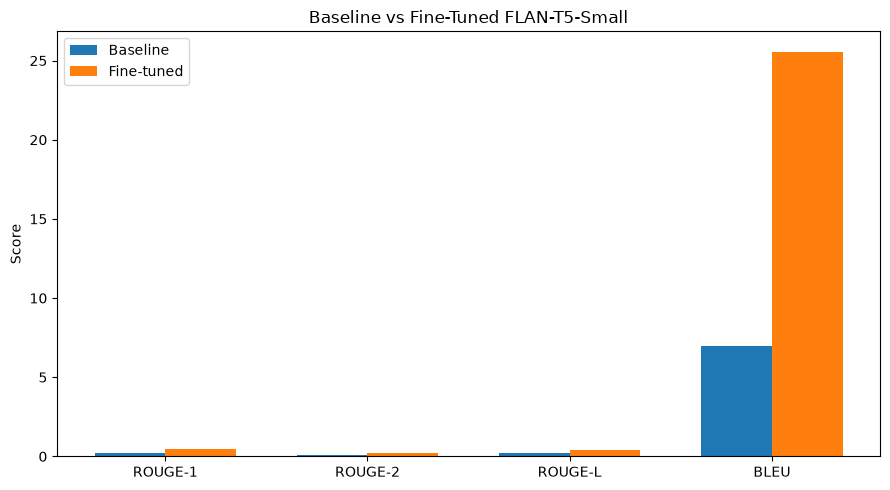

In [40]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]

baseline_scores = [0.2193, 0.0811, 0.1932, 6.96]
fine_tuned_scores = [0.4789, 0.2288, 0.3971, 25.57]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, baseline_scores, width, label="Baseline")
plt.bar(x + width/2, fine_tuned_scores, width, label="Fine-tuned")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Fine-Tuned FLAN-T5-Small")
plt.legend()
plt.tight_layout()

plt.show()

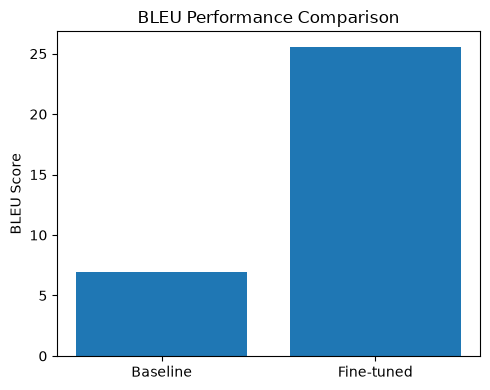

In [41]:
plt.figure(figsize=(5, 4))

plt.bar(
    ["Baseline", "Fine-tuned"],
    [6.96, 25.57]
)

plt.ylabel("BLEU Score")
plt.title("BLEU Performance Comparison")
plt.tight_layout()

plt.show()

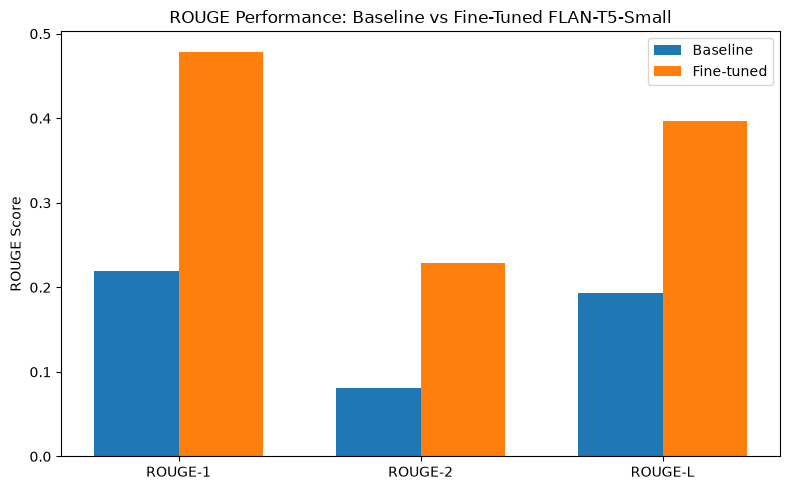

In [42]:
rouge_metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
baseline_rouge = [0.2193, 0.0811, 0.1932]
fine_tuned_rouge = [0.4789, 0.2288, 0.3971]

x = np.arange(len(rouge_metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, baseline_rouge, width, label="Baseline")
plt.bar(x + width/2, fine_tuned_rouge, width, label="Fine-tuned")

plt.xticks(x, rouge_metrics)
plt.ylabel("ROUGE Score")
plt.title("ROUGE Performance: Baseline vs Fine-Tuned FLAN-T5-Small")
plt.legend()

plt.tight_layout()
plt.show()

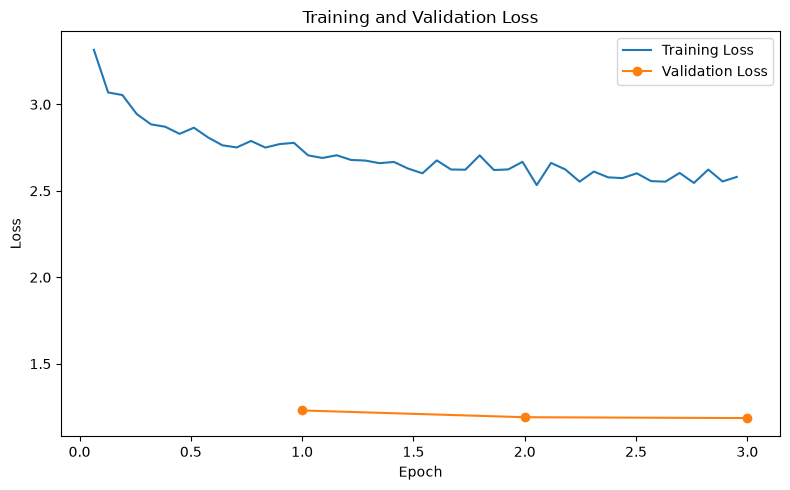

In [43]:
import matplotlib.pyplot as plt

train_epochs = []
train_losses = []

eval_epochs = []
eval_losses = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_losses.append(log["loss"])

    if "eval_loss" in log and "epoch" in log:
        eval_epochs.append(log["epoch"])
        eval_losses.append(log["eval_loss"])

plt.figure(figsize=(8, 5))

plt.plot(train_epochs, train_losses, label="Training Loss")
plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()

plt.show()

In [44]:
import torch


# ---------------------------------------------------------
# Strategy 1: Current generation configuration
# ---------------------------------------------------------
def generate_summary_original(dialogue):
    """
    Generate a summary using the same configuration used
    during our previous evaluation.
    """

    prompt = "Summarize the following dialogue: " + dialogue

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    model.eval()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4
        )

    summary = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return summary


# ---------------------------------------------------------
# Strategy 2: Constrained decoding
# ---------------------------------------------------------
def generate_summary_constrained(dialogue):
    """
    Keep the original training prompt but introduce
    decoding constraints to reduce repetition.
    """

    prompt = "Summarize the following dialogue: " + dialogue

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    model.eval()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,

            # Beam search
            num_beams=4,

            # Prevent repeating the same 3-token sequence
            no_repeat_ngram_size=3,

            # Mild penalty against repeated tokens
            repetition_penalty=1.1,

            # Stop when all beams reach an end token
            early_stopping=True
        )

    summary = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return summary


# ---------------------------------------------------------
# Strategy 3: Grounded prompt + constrained decoding
# ---------------------------------------------------------
def generate_summary_grounded(dialogue):
    """
    Use a stronger instruction together with constrained
    decoding to encourage factual and concise summaries.
    """

    prompt = (
        "Summarize the following dialogue accurately. "
        "Use only information explicitly stated in the dialogue. "
        "Do not invent facts or events. "
        "Preserve the correct speaker relationships. "
        "Keep the summary concise.\n\n"
        "Dialogue:\n"
        + dialogue
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    model.eval()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=1.1,
            early_stopping=True
        )

    summary = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return summary

In [45]:
comparison_results = []

seen_dialogues = set()
sample_count = 0

for example in dataset["test"]:

    dialogue = example["dialogue"]

    # Skip repeated test dialogues
    if dialogue in seen_dialogues:
        continue

    seen_dialogues.add(dialogue)

    reference = example["summary"]

    # Generate with each strategy
    original_prediction = generate_summary_original(dialogue)

    constrained_prediction = generate_summary_constrained(dialogue)

    grounded_prediction = generate_summary_grounded(dialogue)

    comparison_results.append({
        "sample": sample_count + 1,
        "dialogue": dialogue,
        "reference": reference,
        "original": original_prediction,
        "constrained": constrained_prediction,
        "grounded": grounded_prediction
    })

    sample_count += 1

    if sample_count == 10:
        break

In [46]:
for result in comparison_results:

    print("\n" + "=" * 90)
    print(f"SAMPLE {result['sample']}")
    print("=" * 90)

    print("\nREFERENCE SUMMARY:")
    print(result["reference"])

    print("\nORIGINAL FINE-TUNED OUTPUT:")
    print(result["original"])

    print("\nCONSTRAINED DECODING OUTPUT:")
    print(result["constrained"])

    print("\nGROUNDED + CONSTRAINED OUTPUT:")
    print(result["grounded"])


SAMPLE 1

REFERENCE SUMMARY:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

ORIGINAL FINE-TUNED OUTPUT:
Ms. Dawson asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson tells Ms. Dawson that all office communications are restricted to email correspondence and official memos. Ms. Dawson tells Ms. Dawson that the use of instant messaging programs by employees during working hours is strictly prohibited.

CONSTRAINED DECODING OUTPUT:
Ms. Dawson tells #Person1# that all office communications are restricted to email correspondence and official memos. Msa Dawson recommends an intra-office memorandum to all employees by this afternoon.

GROUNDED + CONSTRAINED OUTPUT:
#Person1# asks Ms. Dawson to take a dictation for her. Dawson tells her that all office communications are restricted to email correspondence and official memos, but she doesn't want any - one using Inst

In [47]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Sample": result["sample"],
        "Reference": result["reference"],
        "Original": result["original"],
        "Constrained": result["constrained"],
        "Grounded": result["grounded"]
    }
    for result in comparison_results
])

comparison_df

,Sample,Reference,Original,Constrained,Grounded
0,1,Ms. Dawson helps #Person1# to write a memo to ...,Ms. Dawson asks Ms. Dawson to take a dictation...,Ms. Dawson tells #Person1# that all office com...,#Person1# asks Ms. Dawson to take a dictation ...
1,2,#Person2# arrives late because of traffic jam....,#Person2# got stuck in traffic again because t...,#Person2# got stuck in traffic again because t...,#Person2# got stuck in traffic again because t...
2,3,#Person1# tells Kate that Masha and Hero get d...,Kate tells #Person1# that Masha and Hero are g...,Kate tells #Person1# that Masha and Hero have ...,Kate tells #Person1# that Masha and Hero have ...
3,4,#Person1# and Brian are at the birthday party ...,Brian invites #Person1# to have a dance with #...,Brian invites #Person1# to have a dance with h...,Brian invites #Person1# to have a dance with h...
4,5,#Person1# is surprised at the Olympic Stadium'...,#Person1# and #Person2# are in the Olympic sta...,"#Person2# is in the Olympic stadium, the cente...","#Person2# is in the Olympic stadium, the cente..."
5,6,#Person1# wants to create a company and is goi...,#Person1# tells #Person2# #Person1# is going t...,#Person1# has decided to create a company and ...,#Person1# has decided to create a company and ...
6,7,#Person2# feels itchy. #Person1# doubts it is ...,#Person2# feels itchy because #Person2# is scr...,#Person2# feels itchy and can't stand it anymo...,#Person2# feels itchy and can't stand it anymo...
7,8,#Person2# is checking out and asks #Person1# f...,#Person2# is checking out. #Person1# tells #Pe...,#Person2#'s checking out today and asks for th...,#Person2#'s checking out today. # Person1# tel...
8,9,#Person1# is begging Steven to persuade his wi...,Steven tells #Person1# his wife has an affair ...,Steven tells #Person1# his wife has an affair ...,Steven tells #Person1# his wife has an affair ...
9,10,#Person1# and #Person2# are talking about Abra...,#Person1# and #Person2# are talking about Abra...,#Person2# thinks Abraham Lincoln is famous for...,#Person2# thinks Abraham Lincoln is the US pre...


In [48]:
grounded_predictions = []
grounded_references = []

model.eval()

for dialogue in tqdm(unique_dialogues):

    prediction = generate_summary_grounded(dialogue)

    grounded_predictions.append(prediction)

    grounded_references.append(
        test_references[dialogue]
    )

  0%|          | 0/500 [00:00<?, ?it/s]

In [49]:
grounded_rouge = rouge_metric.compute(
    predictions=grounded_predictions,
    references=grounded_references,
    use_stemmer=True
)

print("Grounded Generation - ROUGE Scores")

for metric_name, score in grounded_rouge.items():
    print(f"{metric_name}: {score:.4f}")

Grounded Generation - ROUGE Scores
rouge1: 0.4615
rouge2: 0.2183
rougeL: 0.3841
rougeLsum: 0.3838


In [50]:
grounded_bleu = bleu_metric.compute(
    predictions=grounded_predictions,
    references=grounded_references
)

print("\nGrounded Generation - BLEU Score:")
print(f"BLEU: {grounded_bleu['score']:.2f}")


Grounded Generation - BLEU Score:
BLEU: 21.52


In [51]:
current_scores = {
    "ROUGE-1": 0.4789,
    "ROUGE-2": 0.2288,
    "ROUGE-L": 0.3971,
    "BLEU": 25.57
}

grounded_scores = {
    "ROUGE-1": grounded_rouge["rouge1"],
    "ROUGE-2": grounded_rouge["rouge2"],
    "ROUGE-L": grounded_rouge["rougeL"],
    "BLEU": grounded_bleu["score"]
}

comparison_metrics = pd.DataFrame({
    "Metric": current_scores.keys(),
    "Current Fine-Tuned": current_scores.values(),
    "Grounded + Constrained": grounded_scores.values()
})

comparison_metrics

,Metric,Current Fine-Tuned,Grounded + Constrained
0,ROUGE-1,0.4789,0.461525
1,ROUGE-2,0.2288,0.218290
2,ROUGE-L,0.3971,0.384128
3,BLEU,25.5700,21.518992


In [52]:
constrained_predictions = []
constrained_references = []

model.eval()

for dialogue in tqdm(unique_dialogues):
    prediction = generate_summary_constrained(dialogue)

    constrained_predictions.append(prediction)
    constrained_references.append(
        test_references[dialogue]
    )

  0%|          | 0/500 [00:00<?, ?it/s]

In [53]:
constrained_rouge = rouge_metric.compute(
    predictions=constrained_predictions,
    references=constrained_references,
    use_stemmer=True
)

print("Constrained Decoding - ROUGE Scores")

for metric_name, score in constrained_rouge.items():
    print(f"{metric_name}: {score:.4f}")

Constrained Decoding - ROUGE Scores
rouge1: 0.4646
rouge2: 0.2170
rougeL: 0.3844
rougeLsum: 0.3840


In [54]:
constrained_bleu = bleu_metric.compute(
    predictions=constrained_predictions,
    references=constrained_references
)

print("\nConstrained Decoding - BLEU Score:")
print(f"BLEU: {constrained_bleu['score']:.2f}")


Constrained Decoding - BLEU Score:
BLEU: 21.49


In [55]:
comparison_results_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU"
    ],

    "Fine-Tuned": [
        0.4789,
        0.2288,
        0.3971,
        25.57
    ],

    "Constrained Decoding": [
        constrained_rouge["rouge1"],
        constrained_rouge["rouge2"],
        constrained_rouge["rougeL"],
        constrained_bleu["score"]
    ],

    "Grounded + Constrained": [
        0.461525,
        0.218290,
        0.384128,
        21.518992
    ]
})

comparison_results_df

,Metric,Fine-Tuned,Constrained Decoding,Grounded + Constrained
0,ROUGE-1,0.4789,0.464573,0.461525
1,ROUGE-2,0.2288,0.216980,0.218290
2,ROUGE-L,0.3971,0.384379,0.384128
3,BLEU,25.5700,21.487105,21.518992


In [58]:
import evaluate

bertscore_metric = evaluate.load("bertscore")

In [59]:
bert_references = [
    references[0]
    for references in baseline_references
]

print("Predictions:", len(baseline_predictions))
print("References:", len(bert_references))

Predictions: 500
References: 500


In [64]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence Transformer loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer loaded successfully.


In [65]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence Transformer loaded successfully.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence Transformer loaded successfully.


In [66]:
def calculate_semantic_similarity(predictions, references, model):
    """
    Calculate semantic similarity between generated summaries
    and their human reference summaries.

    For dialogues with multiple references, the highest
    similarity score is retained.
    """

    similarity_scores = []

    for prediction, reference_list in zip(predictions, references):

        # Generate embedding for model prediction
        prediction_embedding = model.encode(
            prediction,
            normalize_embeddings=True
        )

        # Generate embeddings for all reference summaries
        reference_embeddings = model.encode(
            reference_list,
            normalize_embeddings=True
        )

        # Cosine similarity becomes a dot product because
        # embeddings were normalized
        similarities = np.dot(
            reference_embeddings,
            prediction_embedding
        )

        # Keep the closest valid human reference
        best_similarity = np.max(similarities)

        similarity_scores.append(best_similarity)

    return np.array(similarity_scores)

In [67]:
baseline_semantic_scores = calculate_semantic_similarity(
    baseline_predictions,
    baseline_references,
    semantic_model
)

baseline_semantic_similarity = np.mean(
    baseline_semantic_scores
)

print(
    f"Baseline Semantic Similarity: "
    f"{baseline_semantic_similarity:.4f}"
)

Baseline Semantic Similarity: 0.4438


In [68]:
fine_tuned_semantic_scores = calculate_semantic_similarity(
    fine_tuned_predictions,
    fine_tuned_references,
    semantic_model
)

fine_tuned_semantic_similarity = np.mean(
    fine_tuned_semantic_scores
)

print(
    f"Fine-Tuned Semantic Similarity: "
    f"{fine_tuned_semantic_similarity:.4f}"
)

Fine-Tuned Semantic Similarity: 0.7821


In [69]:
print("\nSemantic Similarity Comparison")
print(
    f"Baseline:   {baseline_semantic_similarity:.4f}"
)
print(
    f"Fine-tuned: {fine_tuned_semantic_similarity:.4f}"
)

improvement = (
    fine_tuned_semantic_similarity
    - baseline_semantic_similarity
)

print(
    f"Absolute Improvement: {improvement:.4f}"
)


Semantic Similarity Comparison
Baseline:   0.4438
Fine-tuned: 0.7821
Absolute Improvement: 0.3383
